<a href="https://colab.research.google.com/github/Simon-Alpha/Quantitative-Finance/blob/main/Data_Collection_and_Visualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install the tool to get financial data
!pip install yfinance

# 2. Import the libraries we need
import yfinance as yf
import pandas as pd

# 3. Choose a stock (Apple)
ticker = yf.Ticker("AAPL")

# 4. Look at the available expiration dates for Apple options
dates = ticker.options
print("Available Expiration Dates:")
print(dates[:5])  # This prints the first 5 upcoming dates

Available Expiration Dates:
('2026-05-26', '2026-05-27', '2026-05-29', '2026-06-05', '2026-06-12')


In [ ]:
# 5. Pick the closest expiration date from the list we just got
chosen_date = dates[0]

# 6. Fetch the options data for that date
option_chain = ticker.option_chain(chosen_date)
calls_data = option_chain.calls

# 7. Clean up the data to show just the important parts
# Strike = the target price bet; impliedVolatility = how wild the market expects it to be
simplified_data = calls_data[['strike', 'lastPrice', 'impliedVolatility']]

print(f"Options Data for expiration date: {chosen_date}")
print(simplified_data.head(10)) # Shows the first 10 rows

Options Data for expiration date: 2026-05-26
   strike  lastPrice  impliedVolatility
0   220.0      89.18           1.679689
1   225.0      84.20           2.132817
2   230.0      61.60           1.031255
3   235.0      58.65           1.292972
4   240.0      62.20           1.267582
5   245.0      48.95           1.301761
6   250.0      46.50           1.029302
7   255.0      43.20           1.017583
8   260.0      36.11           0.859376
9   265.0      44.19           0.839845


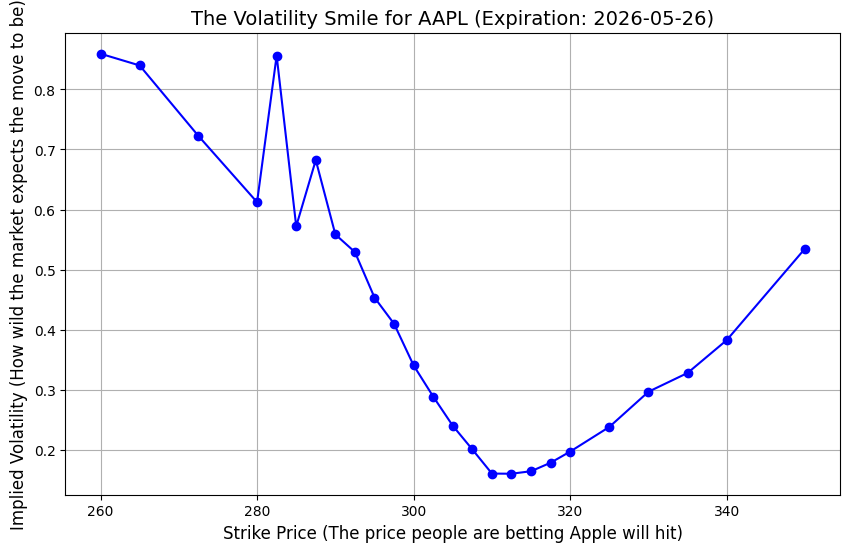

In [ ]:
import matplotlib.pyplot as plt

# 1. Filter out extreme, unrealistic data points to make the graph look clean
# We only want options where the implied volatility is greater than 0 and less than 100% (1.0)
clean_data = simplified_data[(simplified_data['impliedVolatility'] > 0) & (simplified_data['impliedVolatility'] < 1.0)]

# 2. Create the plot
plt.figure(figsize=(10, 6))
plt.plot(clean_data['strike'], clean_data['impliedVolatility'], marker='o', color='b', linestyle='-')

# 3. Add labels so we know what we are looking at
plt.title(f"The Volatility Smile for AAPL (Expiration: {chosen_date})", fontsize=14)
plt.xlabel("Strike Price (The price people are betting Apple will hit)", fontsize=12)
plt.ylabel("Implied Volatility (How wild the market expects the move to be)", fontsize=12)
plt.grid(True)

# 4. Show the graph
plt.show()

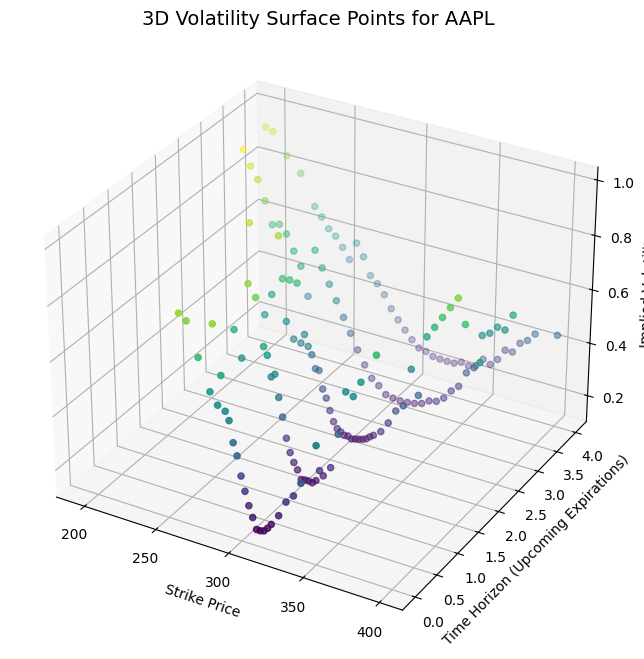

In [ ]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 1. Create lists to hold our data points
all_strikes = []
all_times = []
all_vols = []

# 2. Loop through the first 5 expiration dates and grab data for each
for i, d in enumerate(dates[:5]):
    chain = ticker.option_chain(d).calls
    # Clean the data like before
    chain = chain[(chain['impliedVolatility'] > 0) & (chain['impliedVolatility'] < 1.0)]

    # Save the strike prices and volatilities
    all_strikes.extend(chain['strike'].tolist())
    all_vols.extend(chain['impliedVolatility'].tolist())

    # Save the time (we will just use the index 0, 1, 2, 3, 4 as a proxy for time)
    all_times.extend([i] * len(chain))

# 3. Create a 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 4. Scatter plot the points in 3D space
ax.scatter(all_strikes, all_times, all_vols, c=all_vols, cmap='viridis')

# 5. Add 3D labels
ax.set_title("3D Volatility Surface Points for AAPL", fontsize=14)
ax.set_xlabel("Strike Price")
ax.set_ylabel("Time Horizon (Upcoming Expirations)")
ax.set_zlabel("Implied Volatility")

plt.show()

In [ ]:
import numpy as np
from scipy.stats import norm

# Define the classic Black-Scholes formula for a Call Option
def black_scholes_call(S, K, T, r, sigma):
    """
    S: Current Stock Price
    K: Strike Price
    T: Time to Expiration (in years)
    r: Risk-free interest rate (e.g., 0.05 for 5%)
    sigma: Volatility (e.g., 0.20 for 20%)
    """
    # If time to expiration is 0, the option value is just its immediate payoff
    if T <= 0:
        return max(0.0, S - K)

    # The math underlying the Black-Scholes formula
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Calculate the theoretical price
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# Let's test it with dummy numbers:
# Stock price = $180, Strike = $185, 3 months left (0.25 years), 5% interest rate, 20% volatility
test_price = black_scholes_call(S=180, K=185, T=0.25, r=0.05, sigma=0.20)
print(f"Theoretical Black-Scholes Option Price: ${test_price:.2f}")

Theoretical Black-Scholes Option Price: $5.96


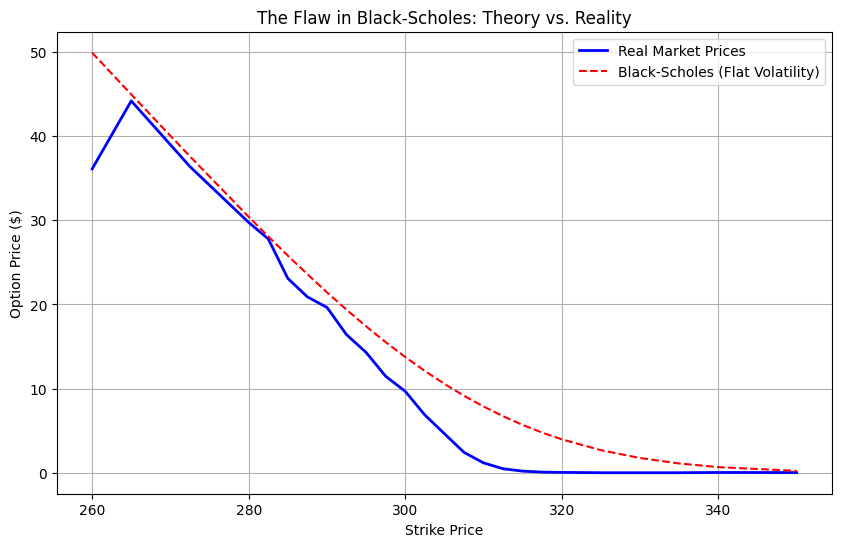

In [ ]:
# 1. Grab the current price of Apple stock
current_price = ticker.history(period="1d")['Close'].iloc[-1]

# 2. Let's look at our real data from Step 3 again
# We will assume a 5% interest rate (0.05) and rough time to maturity of 1 month (1/12 of a year)
r = 0.05
T = 1/12
assumed_flat_vol = 0.22  # Let's guess a flat 22% volatility

bs_prices = []

# 3. Calculate what Black-Scholes thinks the price should be for each strike
for strike in clean_data['strike']:
    bs_p = black_scholes_call(S=current_price, K=strike, T=T, r=r, sigma=assumed_flat_vol)
    bs_prices.append(bs_p)

# 4. Plot Black-Scholes vs Reality
plt.figure(figsize=(10, 6))
plt.plot(clean_data['strike'], clean_data['lastPrice'], label='Real Market Prices', color='blue', linewidth=2)
plt.plot(clean_data['strike'], bs_prices, label='Black-Scholes (Flat Volatility)', color='red', linestyle='--')
plt.xlabel("Strike Price")
plt.ylabel("Option Price ($)")
plt.title("The Flaw in Black-Scholes: Theory vs. Reality")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import scipy.integrate as integrate

def heston_call_price(S, K, T, r, v0, kappa, theta, sigma, rho):
    """
    S: Current stock price
    K: Strike price
    T: Time to maturity
    r: Risk-free rate
    v0: Initial variance (current volatility squared)
    kappa: Mean-reversion speed (how fast volatility returns to average)
    theta: Long-term variance (the average volatility weather)
    sigma: Volatility of volatility (how wildly the volatility bounces around)
    rho: Correlation between stock returns and volatility shocks
    """

    # Inner mathematical characteristic function for Heston
    def characteristic_function(u, type_num):
        # Set parameters based on the phase component (type 1 or type 2)
        b = kappa + 1 - rho * sigma if type_num == 1 else kappa
        u_i = 1j * u

        # Intermediate algebraic steps of the SDE solution
        d = np.sqrt((rho * sigma * u_i - b)**2 - sigma**2 * (2 * (1j if type_num == 1 else -1j) * 0.5 * u - u**2))
        g = (b - rho * sigma * u_i + d) / (b - rho * sigma * u_i - d)

        # Calculate complex exponential components
        C = (r * u_i * T + (kappa * theta / sigma**2) * ((b - rho * sigma * u_i + d) * T - 2 * np.log((1 - g * np.exp(d * T)) / (1 - g))))
        D = ((b - rho * sigma * u_i + d) / sigma**2) * ((1 - np.exp(d * T)) / (1 - g * np.exp(d * T)))

        return np.exp(C + D * v0 + 1j * u * np.log(S))

    # Integrand for the Fourier transform inversion
    def integrand(u, type_num):
        denom = 1j * u * np.exp(1j * u * np.log(K))
        return (characteristic_function(u, type_num) / denom).real

    # Numerically integrate from 0 to infinity using SciPy
    # This solves the complex integral required by the Fourier inversion
    p1 = 0.5 + (1 / np.pi) * integrate.quad(integrand, 0, 100, args=(1,))[0]
    p2 = 0.5 + (1 / np.pi) * integrate.quad(integrand, 0, 100, args=(2,))[0]

    # Final Heston Option Price formula
    price = S * p1 - K * np.exp(-r * T) * p2
    return max(0.0, price)

# Let's test our engine with some standard Heston parameters
test_heston = heston_call_price(S=180, K=185, T=0.25, r=0.05,
                                v0=0.04, kappa=2.0, theta=0.04, sigma=0.3, rho=-0.7)
print(f"Theoretical Heston Option Price: ${test_heston:.2f}")

Theoretical Heston Option Price: $4.92


In [ ]:
# Price an option when volatility is stable (sigma = 0.1)
stable_market = heston_call_price(S=180, K=185, T=0.25, r=0.05, v0=0.04, kappa=2.0, theta=0.04, sigma=0.1, rho=-0.7)

# Price an option when volatility is wildly unpredictable (sigma = 0.6)
chaotic_market = heston_call_price(S=180, K=185, T=0.25, r=0.05, v0=0.04, kappa=2.0, theta=0.04, sigma=0.6, rho=-0.7)

print(f"Option Price in a Stable Volatility Market: ${stable_market:.2f}")
print(f"Option Price in a Chaotic Volatility Market: ${chaotic_market:.2f}")

Option Price in a Stable Volatility Market: $5.15
Option Price in a Chaotic Volatility Market: $4.16


In [ ]:
from scipy.optimize import minimize

# 1. Take a small sample of 5 real options to keep the calibration fast
sample_data = clean_data.iloc[::len(clean_data)//5].head(5)
market_prices = sample_data['lastPrice'].values
strikes = sample_data['strike'].values

# 2. Define our "Error Function" (Loss Function)
# This calculates how wrong our model is compared to the real market
def heston_error(parameters):
    v0, kappa, theta, sigma, rho = parameters

    # Penalty if the math violates reality constraints (e.g., negative volatility)
    if v0 <= 0 or kappa <= 0 or theta <= 0 or sigma <= 0 or rho < -1 or rho > 1:
        return 1e6
    # Feller condition check (prevents variance from hitting zero in continuous time)
    if 2 * kappa * theta < sigma**2:
        return 1e6

    total_squared_error = 0.0

    # Calculate Heston price for each strike and compare to market price
    for i in range(len(strikes)):
        model_price = heston_call_price(S=current_price, K=strikes[i], T=T, r=r,
                                        v0=v0, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
        total_squared_error += (model_price - market_prices[i])**2

    return total_squared_error

# 3. Set initial starting guesses for our parameters [v0, kappa, theta, sigma, rho]
initial_guess = [0.04, 2.0, 0.04, 0.3, -0.7]

print("Starting Calibration... (This may take 10-30 seconds as it runs calculus loops)")

# 4. Run the optimizer using the Nelder-Mead algorithm
result = minimize(heston_error, initial_guess, method='Nelder-Mead', options={'maxiter': 50})

# 5. Extract our optimized parameters!
opt_v0, opt_kappa, opt_theta, opt_sigma, opt_rho = result.x

print("\n--- CALIBRATION SUCCESSFUL ---")
print(f"Optimized Current Variance (v0): {opt_v0:.4f}")
print(f"Optimized Mean-Reversion Speed (kappa): {opt_kappa:.4f}")
print(f"Optimized Long-Term Variance (theta): {opt_theta:.4f}")
print(f"Optimized Vol of Vol (sigma): {opt_sigma:.4f}")
print(f"Optimized Stock/Vol Correlation (rho): {opt_rho:.4f}")

Starting Calibration... (This may take 10-30 seconds as it runs calculus loops)

--- CALIBRATION SUCCESSFUL ---
Optimized Current Variance (v0): 0.0004
Optimized Mean-Reversion Speed (kappa): 2.3540
Optimized Long-Term Variance (theta): 0.0372
Optimized Vol of Vol (sigma): 0.3721
Optimized Stock/Vol Correlation (rho): -0.9769
